# 01 - Data Understanding: Data Quality Inspection
---
This notebook performs an initial inspection of the dataset in order to verify data quality issues:
1. Accuracy: conformity of the stored value to the actual value.
2. Completeness: no missing values.
3. Consistency: uniform representation.
4. Up-to-dateness: stored data is not obsolete.

It loads the dataset from `data/raw/` and :
- identifies the presence of missing values;
- check the class balance;
- identifies the presence of duplicate values.

The notebook does not perform the final cleaning phase and does not store the cleaned dataset.

## Import libraries and settings

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Any

from myocardial_infarction_mortality.config import (
    RAW_DATA_DIR,
    RAW_FILENAME,
    FIGURES_DIR,
)

In [26]:
input_path: Path = RAW_DATA_DIR / RAW_FILENAME
print(f"Loading dataset at path:\n\t{input_path}")

Loading dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/data/raw/myocardial_infarction_raw.csv


In [27]:
FIGURES_DATA_QUALITY_DIR: Path = FIGURES_DIR / "DU_data_quality_inspection"
FIGURES_DATA_QUALITY_DIR.mkdir(parents=True, exist_ok=True)

In [28]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading
We begin by loading the myocardial infarction mortality dataset. This is the untouched file downloaded from ucimlrepo.


In [29]:
df: pd.DataFrame = pd.read_csv(input_path, header=0, index_col=0, sep=",")
print(f"Dataset dimension\n"
      f"\t-Number of rows = {df.shape[0]}\n"
      f"\t-Number of cols = {df.shape[1]}")

Dataset dimension
	-Number of rows = 1700
	-Number of cols = 123


In [30]:
df.head(10)

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr_11,nr_01,nr_02,nr_03,nr_04,nr_07,nr_08,np_01,np_04,np_05,np_07,np_08,np_09,np_10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_KBRIG,D_AD_KBRIG,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,GIPO_K,K_BLOOD,GIPER_NA,NA_BLOOD,ALT_BLOOD,AST_BLOOD,KFK_BLOOD,L_BLOOD,ROE,TIME_B_S,R_AB_1_n,R_AB_2_n,R_AB_3_n,NA_KB,NOT_NA_KB,LID_KB,NITR_S,NA_R_1_n,NA_R_2_n,NA_R_3_n,NOT_NA_1_n,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,FIBR_PREDS,PREDS_TAH,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,180.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.7,0.0,138.0,NaN,NaN,NaN,8.0,16.0,4.0,0.0,0.0,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0
2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,120.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.5,0.0,132.0,0.38,0.18,NaN,7.8,3.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0
3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,100.0,180.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,132.0,0.30,0.11,NaN,10.8,NaN,3.0,3.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0
4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,120.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.9,0.0,146.0,0.75,0.37,NaN,NaN,NaN,2.0,0.0,0.0,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,0,0
5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,190.0,100.0,160.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.5,0.0,132.0,0.45,0.22,NaN,8.3,NaN,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0
6,64.0,1,0.0,1.0,2.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,140.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [31]:
df.tail(10)

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr_11,nr_01,nr_02,nr_03,nr_04,nr_07,nr_08,np_01,np_04,np_05,np_07,np_08,np_09,np_10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_KBRIG,D_AD_KBRIG,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,GIPO_K,K_BLOOD,GIPER_NA,NA_BLOOD,ALT_BLOOD,AST_BLOOD,KFK_BLOOD,L_BLOOD,ROE,TIME_B_S,R_AB_1_n,R_AB_2_n,R_AB_3_n,NA_KB,NOT_NA_KB,LID_KB,NITR_S,NA_R_1_n,NA_R_2_n,NA_R_3_n,NOT_NA_1_n,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,FIBR_PREDS,PREDS_TAH,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1691,77.0,1,0.0,0.0,0.0,0.0,NaN,2.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,140.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.4,13.0,5.0,0.0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,0,3
1692,62.0,1,0.0,0.0,0.0,0.0,NaN,0.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,140.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.9,0.0,133.0,0.15,0.07,NaN,10.5,3.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,2.0,NaN,NaN,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,3
1693,71.0,0,0.0,6.0,2.0,2.0,NaN,2.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,110.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.4,0.0,133.0,0.52,0.22,NaN,5.1,8.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1,0,0,0,0,0,1,0,0,1,0,3
1694,70.0,0,0.0,2.0,2.0,1.0,NaN,2.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,140.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.52,0.48,NaN,NaN,NaN,1.0,0.0,NaN,NaN,1.0,1.0,1.0,0.0,0.0,NaN,NaN,1.0,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,3
1695,77.0,0,0.0,0.0,0.0,0.0,NaN,2.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,150.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.9,0.0,136.0,0.23,0.18,NaN,5.5,20.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,3
1696,77.0,0,0.0,4.0,2.0,1.0,NaN,2.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,110.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1700 entries, 1 to 1700
Columns: 123 entries, AGE to LET_IS
dtypes: float64(110), int64(13)
memory usage: 1.6 MB


## Missing Values Analysis

### Visual Inspection
**Goal**: quickly spot where missingness occurs and whether it is random or structured.

**What to look for in the heatmap**:

- **Entire vertical bands** (a column almost fully missing) → likely an ingestion/extraction issue or a feature not available for many patients.

- **Horizontal bands** (many columns missing for specific patients) → potentially incomplete patient records or filtering/join errors.

- **Blocks/rectangles** → missingness tied to **sub-cohorts, time windows, devices, or clinical pathways** (systematic bias risk).

- **Sparse scattered points** → more consistent with random missing values (but still verify).

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DU_data_quality_inspection/missing_values_heatmap.png


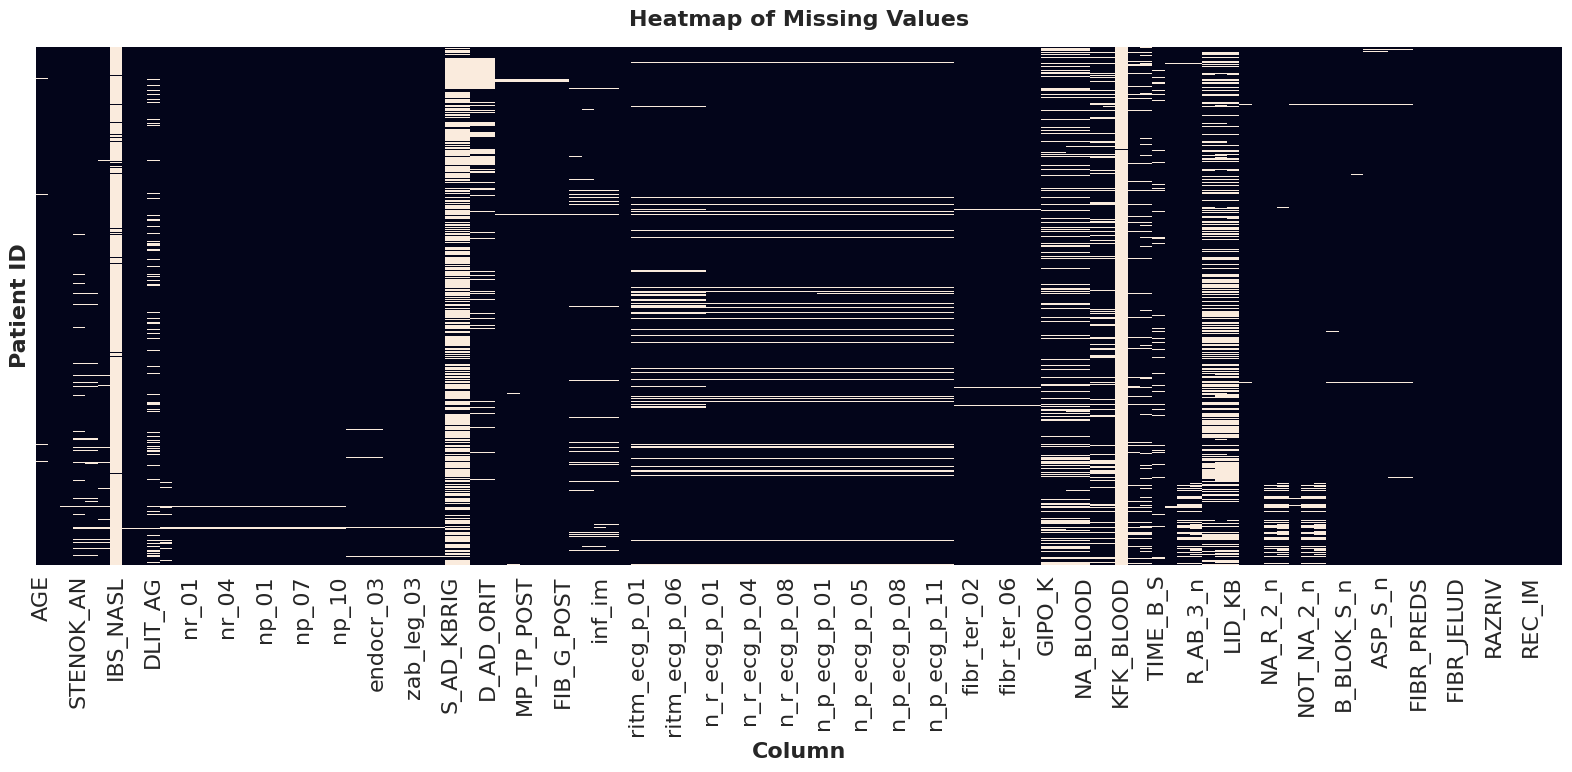

In [33]:
plt.figure(figsize=(16, 8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.xlabel("Column", fontweight="bold")
plt.ylabel("Patient ID", fontweight="bold")
plt.xticks(rotation=90)
plt.title("Heatmap of Missing Values",
          fontsize=16,
          fontweight="bold",
          pad=15
          )
plt.tight_layout()

missing_values_heatmap_path: Path = FIGURES_DATA_QUALITY_DIR / "missing_values_heatmap.png"
plt.savefig(FIGURES_DATA_QUALITY_DIR / missing_values_heatmap_path, dpi=300)
print(f"[SAVED] {missing_values_heatmap_path}")

plt.show()

### Row-Level Analysis
**Goal**: quantify record completeness at the row level by counting how many rows contain at least one missing value.
We report both:

- **Absolute count** of rows with any missing value

- **Percentage** over the full dataset

**Interpretation**:

- A **high percentage** means missingness is widespread across patient records (may affect model training and evaluation).

- A **low percentage** suggests missingness is concentrated in fewer records (row-wise dropping may be acceptable, depending on context).

In [34]:
# Total rows
n_rows: int = df.shape[0]

# Boolean mask: True if a row has at least one missing value
rows_with_missing: np.ndarray = df.isnull().any(axis=1).to_numpy()

# Absolute count
n_rows_with_missing: int = int(rows_with_missing.sum())

# Percentage
pct_rows_with_missing: float = (n_rows_with_missing / n_rows * 100.0) if n_rows > 0 else 0.0

print(f"Total rows: {n_rows}")
print(f"Rows with ≥1 missing value: {n_rows_with_missing}/{n_rows} ({pct_rows_with_missing:.2f}/100.00%)")

Total rows: 1700
Rows with ≥1 missing value: 1700/1700 (100.00/100.00%)


Since **100% of rows have at least one missing value**, the next step is to measure **severity** of missingness per row.

We compute, for each row:

- `row_missing_pct` = (number of missing cells in the row) / (number of columns)

Then we evaluate multiple thresholds (e.g., 5%, 10%, 20%, …) and count:

- how many rows have **more than X%** missing values (absolute + percentage)

This helps decide whether to:

- drop very incomplete rows,

- apply targeted imputation,

- or re-check data joins/pipeline issues if missingness is systematically high.

In [35]:
# Compute per-row missingness (fraction and percentage)
# We want to quantify row by row how many missing values we have,
# in order to compute some statistics to quantify on average the missingness.
n_rows: int = df.shape[0]
n_cols: int = df.shape[1]

row_missing_frac: np.ndarray = df.isnull().mean(axis=1).to_numpy()          # in [0, 1]
row_missing_pct: np.ndarray = row_missing_frac * 100.0                      # in [0, 100]

# Quick sanity prints
print(f"Rows: {n_rows}, Columns: {n_cols}")
print(
    "Row missingness (pct) summary:",
    f"\n\t- min={row_missing_pct.min():.2f}%    (best-case record completeness)",
    f"\n\t- median={np.median(row_missing_pct):.2f}% (typical row missingness)",
    f"\n\t- mean={row_missing_pct.mean():.2f}%   (average missingness)",
    f"\n\t- max={row_missing_pct.max():.2f}%   (worst-case record)",
)

Rows: 1700, Columns: 123
Row missingness (pct) summary: 
	- min=0.81%    (best-case record completeness) 
	- median=5.69% (typical row missingness) 
	- mean=7.64%   (average missingness) 
	- max=48.78%   (worst-case record)


In [36]:
# Define thresholds and compute counts for rows with missingness > threshold
thresholds_pct: np.ndarray = np.arange(0, 101, 5, dtype=float)

counts: list[int] = []
percents: list[float] = []

for t in thresholds_pct:
    n_above: int = int((row_missing_pct > t).sum())
    p_above: float = (n_above / n_rows * 100.0) if n_rows > 0 else 0.0
    counts.append(n_above)
    percents.append(p_above)

rows_missing_threshold_df: pd.DataFrame = pd.DataFrame(
    {
        "threshold_missing_pct": thresholds_pct,
        "n_rows_missing_gt_threshold": counts,
        "pct_rows_missing_gt_threshold": percents,
    }
)

# Show how many rows have missingness <= threshold (complement)
rows_missing_threshold_df["n_rows_missing_le_threshold"] = n_rows - rows_missing_threshold_df["n_rows_missing_gt_threshold"]
rows_missing_threshold_df["pct_rows_missing_le_threshold"] = 100.0 - rows_missing_threshold_df["pct_rows_missing_gt_threshold"]

rows_missing_threshold_df

,threshold_missing_pct,n_rows_missing_gt_threshold,pct_rows_missing_gt_threshold,n_rows_missing_le_threshold,pct_rows_missing_le_threshold
0,0.0,1700,100.000000,0,0.000000
1,5.0,992,58.352941,708,41.647059
2,10.0,314,18.470588,1386,81.529412
3,15.0,168,9.882353,1532,90.117647
4,20.0,134,7.882353,1566,92.117647
5,25.0,93,5.470588,1607,94.529412
6,30.0,29,1.705882,1671,98.294118
7,35.0,4,0.235294,1696,99.764706
8,40.0,2,0.117647,1698,99.882353
9,45.0,1,0.058824,1699,99.941176


In [37]:
rows_missing_threshold_path: Path = FIGURES_DATA_QUALITY_DIR / "rows_missing_thresholds.csv"
rows_missing_threshold_df.to_csv(rows_missing_threshold_path, index=False)
print(f"[SAVED] {rows_missing_threshold_path}")

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DU_data_quality_inspection/rows_missing_thresholds.csv


### Column-Level Analysis
**Goals**:

1. Quantify missingness **per column** (absolute count + percentage).

2. Rank columns by missingness to immediately identify:

    - near-empty variables (likely drop or re-extract),

    - moderately missing variables (candidate for imputation),

    - fully observed variables (safe baseline set).

**What to look for**:

- Columns with **very high missing** % (e.g., >50–80%): usually not reliable unless clinically critical.

- Groups of related columns with similar missingness: may indicate a systematic issue (e.g., a whole modality missing).

In [38]:
# Compute missingness per column
n_rows: int = df.shape[0]

col_missing_count: pd.Series = df.isnull().sum(axis=0)
col_missing_pct: pd.Series = (col_missing_count / n_rows * 100.0) if n_rows > 0 else (col_missing_count * 0.0)

missing_by_column_df: pd.DataFrame = (
    pd.DataFrame(
        {
            "column": col_missing_count.index.astype(str),
            "missing_count": col_missing_count.values.astype(int),
            "missing_pct": col_missing_pct.values.astype(float),
        }
    )
    .sort_values(by=["missing_pct", "missing_count"], ascending=False)
    .reset_index(drop=True)
)

missing_by_column_df

,column,missing_count,missing_pct
0,KFK_BLOOD,1696,99.764706
1,IBS_NASL,1628,95.764706
2,S_AD_KBRIG,1076,63.294118
3,D_AD_KBRIG,1076,63.294118
4,NOT_NA_KB,686,40.352941
...,...,...,...
118,DRESSLER,0,0.000000
119,ZSN,0,0.000000
120,REC_IM,0,0.000000
121,P_IM_STEN,0,0.000000


In [39]:
missing_by_column_path: Path = FIGURES_DATA_QUALITY_DIR / "missingness_by_column.csv"
missing_by_column_df.to_csv(missing_by_column_path, index=False)
print(f"[SAVED] {missing_by_column_path}")

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DU_data_quality_inspection/missingness_by_column.csv


In [40]:
bins = [-0.1, 0, 1, 5, 10, 20, 50, 80, 100.0]
labels = ["0%", "(0-1]%", "(1-5]%", "(5-10]%", "(10-20]%", "(20-50]%", "(50-80]%", "(80-100]%"]

missing_by_column_df["missing_bin"] = pd.cut(missing_by_column_df["missing_pct"], bins=bins, labels=labels)

bin_summary_df: pd.DataFrame = (
    missing_by_column_df["missing_bin"]
    .value_counts(dropna=False)
    .rename_axis("missing_bin")
    .reset_index(name="n_columns")
    .sort_values(by=["missing_bin"], ascending=True)
)

bin_summary_df

,missing_bin,n_columns
3,0%,13
0,(0-1]%,37
2,(1-5]%,21
1,(5-10]%,35
5,(10-20]%,6
4,(20-50]%,7
6,(50-80]%,2
7,(80-100]%,2


In [41]:
bin_features_path: Path = FIGURES_DATA_QUALITY_DIR / "missingness_by_column_bins_features.csv"
bin_summary_df.to_csv(bin_features_path, index=False)
print(f"[SAVED] {bin_features_path}")

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DU_data_quality_inspection/missingness_by_column_bins_features.csv


## Duplicate Row Detection

Duplicate occurrences may occur due to export processes or data corruption. They can bias models and falsely inflate evaluation metrics.

- **Justification:** In medical domain each record represent a specific patient, so duplication of the medical record of the very same patient is not possible.

- **Utility:** Ensures that each record is a unique patient medical information.

### Check duplicate by all columns (Features + Class)

In [42]:
# Total number of rows
n_rows: int = df.shape[0]

# Total number of duplicated rows
# df.duplicated(keep='first') returns False for each unique row;
# df.duplicated(keep='first') returns True if a row is identical to a preceding row.
n_duplicates: int = int(df.duplicated(keep="first").sum())
pct_duplicates: float = (n_duplicates / n_rows * 100.0) if n_rows > 0 else 0.0

print(f"Number of duplicate rows: {n_duplicates}/{n_rows} ({pct_duplicates:.3f}%)")

Number of duplicate rows: 0/1700 (0.000%)


In [43]:
dup_summary_df: pd.DataFrame = pd.DataFrame(
    [{
        "n_total_rows": n_rows,
        "n_duplicate_rows": n_duplicates,
        "pct_duplicate_rows": pct_duplicates,
        "keep_policy": "keep='first'",
        "scope": "full_df",
    }]
)
dup_summary_df

,n_total_rows,n_duplicate_rows,pct_duplicate_rows,keep_policy,scope
0,1700,0,0.0,keep='first',full_df


In [44]:
dup_summary_path: Path = FIGURES_DATA_QUALITY_DIR / "duplicate_rows_summary.csv"
dup_summary_df.to_csv(dup_summary_path, index=False)
print(f"[SAVED] {dup_summary_path}")

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DU_data_quality_inspection/duplicate_rows_summary.csv


## Class Balance
We inspect the different target distribution to check class balance.

- **Justification:** In medical domains detection, we expect a very small percentage of patients to be in severe (or lethal) conditions.

In [45]:
targets: list[str] = [
    "FIBR_PREDS",
    "PREDS_TAH",
    "JELUD_TAH",
    "A_V_BLOK",
    "OTEK_LANC",
    "RAZRIV",
    "DRESSLER",
    "ZSN",
    "REC_IM",
    "P_IM_STEN",
    "LET_IS",
]

rows = []

for target in targets:
    if target not in df.columns:
        print(f"[WARN] Target column not found: {target}")
        continue

    print(f"{'='*80}\nSAMPLES DISTRIBUTION BY: {target}\n{'='*80}")

    class_counts = df[target].value_counts(dropna=False)
    total: int = int(class_counts.sum())

    for label, count in class_counts.items():
        pct: float = (count / total * 100.0) if total > 0 else 0.0
        print(f"\t-Class {label}: {count} ({pct:.3f}%)")

        rows.append(
            {
                "target": target,
                "class_label": label,
                "count": int(count),
                "pct": pct,
                "total": total,
            }
        )

print(f"{'='*80}")

SAMPLES DISTRIBUTION BY: FIBR_PREDS
	-Class 0: 1530 (90.000%)
	-Class 1: 170 (10.000%)
SAMPLES DISTRIBUTION BY: PREDS_TAH
	-Class 0: 1680 (98.824%)
	-Class 1: 20 (1.176%)
SAMPLES DISTRIBUTION BY: JELUD_TAH
	-Class 0: 1658 (97.529%)
	-Class 1: 42 (2.471%)
SAMPLES DISTRIBUTION BY: A_V_BLOK
	-Class 0: 1643 (96.647%)
	-Class 1: 57 (3.353%)
SAMPLES DISTRIBUTION BY: OTEK_LANC
	-Class 0: 1541 (90.647%)
	-Class 1: 159 (9.353%)
SAMPLES DISTRIBUTION BY: RAZRIV
	-Class 0: 1646 (96.824%)
	-Class 1: 54 (3.176%)
SAMPLES DISTRIBUTION BY: DRESSLER
	-Class 0: 1625 (95.588%)
	-Class 1: 75 (4.412%)
SAMPLES DISTRIBUTION BY: ZSN
	-Class 0: 1306 (76.824%)
	-Class 1: 394 (23.176%)
SAMPLES DISTRIBUTION BY: REC_IM
	-Class 0: 1541 (90.647%)
	-Class 1: 159 (9.353%)
SAMPLES DISTRIBUTION BY: P_IM_STEN
	-Class 0: 1552 (91.294%)
	-Class 1: 148 (8.706%)
SAMPLES DISTRIBUTION BY: LET_IS
	-Class 0: 1429 (84.059%)
	-Class 1: 110 (6.471%)
	-Class 3: 54 (3.176%)
	-Class 7: 27 (1.588%)
	-Class 6: 27 (1.588%)
	-Class 4: 23 (

In [46]:
targets_class_dist_df: pd.DataFrame = pd.DataFrame(rows).sort_values(
    by=["target", "count"],
    ascending=[True, False],
).reset_index(drop=True)

targets_class_dist_df

,target,class_label,count,pct,total
0,A_V_BLOK,0,1643,96.647059,1700
1,A_V_BLOK,1,57,3.352941,1700
2,DRESSLER,0,1625,95.588235,1700
3,DRESSLER,1,75,4.411765,1700
4,FIBR_PREDS,0,1530,90.000000,1700
5,FIBR_PREDS,1,170,10.000000,1700
6,JELUD_TAH,0,1658,97.529412,1700
7,JELUD_TAH,1,42,2.470588,1700
8,LET_IS,0,1429,84.058824,1700
9,LET_IS,1,110,6.470588,1700


In [47]:
targets_class_dist_path: Path = FIGURES_DATA_QUALITY_DIR / "targets_class_distribution.csv"
targets_class_dist_df.to_csv(targets_class_dist_path, index=False)
print(f"[SAVED] {targets_class_dist_path}")

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DU_data_quality_inspection/targets_class_distribution.csv


## One-value predominance (per-feature value counts)

**Goal**: detect **near-constant features** (a single value dominates), which can be:

- useless for prediction (low variance),

- artifacts of encoding/default values (e.g., 0 meaning “missing”),

- candidates for removal or special handling.

In [48]:
VALUE_COUNTS_INCLUDE_NA: bool = False  # set True if you want NaN included as a "value"
PREDOMINANCE_THRESHOLD_PCT: float = 99.0  # e.g., 95.0 or 99.0
MAX_LEVELS_STORED: int = 20  # store top-N levels for flagged features

rows: list[dict[str, Any]] = []

for col in df.columns:
    s = df[col]

    vc = s.value_counts(dropna=not VALUE_COUNTS_INCLUDE_NA)

    n_non_missing: int = int(s.notnull().sum())
    n_missing: int = int(s.isnull().sum())
    n_total: int = int(len(s))

    n_unique: int = int(s.nunique(dropna=not VALUE_COUNTS_INCLUDE_NA))

    if len(vc) == 0:
        # Column is fully missing (should already be detectable from missingness analysis)
        top_value = np.nan
        top_count = 0
        top_pct = 0.0
        second_value = np.nan
        second_count = 0
        second_pct = 0.0
    else:
        top_value = vc.index[0]
        top_count = int(vc.iloc[0])
        denominator = n_total if VALUE_COUNTS_INCLUDE_NA else n_non_missing
        top_pct = (top_count / denominator * 100.0) if denominator > 0 else 0.0

        if len(vc) > 1:
            second_value = vc.index[1]
            second_count = int(vc.iloc[1])
            second_pct = (second_count / denominator * 100.0) if denominator > 0 else 0.0
        else:
            second_value = np.nan
            second_count = 0
            second_pct = 0.0

    is_predominant: bool = bool(top_pct >= PREDOMINANCE_THRESHOLD_PCT)

    rows.append(
        {
            "column": str(col),
            "dtype": str(s.dtype),
            "n_total": n_total,
            "n_non_missing": n_non_missing,
            "n_missing": n_missing,
            "n_unique": n_unique,
            "top_value": top_value,
            "top_count": top_count,
            "top_pct": float(top_pct),
            "second_value": second_value,
            "second_count": second_count,
            "second_pct": float(second_pct),
            "predominance_threshold_pct": float(PREDOMINANCE_THRESHOLD_PCT),
            "is_one_value_predominant": is_predominant,
        }
    )

one_value_predominance_df: pd.DataFrame = (
    pd.DataFrame(rows)
    .sort_values(by=["is_one_value_predominant", "top_pct", "n_missing"], ascending=[False, False, False])
    .reset_index(drop=True)
)

one_value_predominance_df

,column,dtype,n_total,n_non_missing,n_missing,n_unique,top_value,top_count,top_pct,second_value,second_count,second_pct,predominance_threshold_pct,is_one_value_predominant
0,np_07,float64,1700,1682,18,2,0.0,1681,99.940547,1.0,1,0.059453,99.0,True
1,nr_07,float64,1700,1679,21,2,0.0,1678,99.940441,1.0,1,0.059559,99.0,True
2,ritm_ecg_p_06,float64,1700,1548,152,2,0.0,1547,99.935401,1.0,1,0.064599,99.0,True
3,fibr_ter_08,float64,1700,1690,10,2,0.0,1688,99.881657,1.0,2,0.118343,99.0,True
4,np_01,float64,1700,1682,18,2,0.0,1680,99.881094,1.0,2,0.118906,99.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,S_AD_KBRIG,float64,1700,624,1076,30,140.0,91,14.583333,130.0,77,12.339744,99.0,False
119,ROE,float64,1700,1497,203,58,5.0,134,8.951236,3.0,126,8.416834,99.0,False
120,K_BLOOD,float64,1700,1329,371,51,4.0,101,7.599699,3.8,91,6.847254,99.0,False
121,AGE,float64,1700,1692,8,62,63.0,90,5.319149,65.0,81,4.787234,99.0,False


In [49]:
pred_summary_path: Path = FIGURES_DATA_QUALITY_DIR / "one_value_predominance_summary.csv"
one_value_predominance_df.to_csv(pred_summary_path, index=False)
print(f"[SAVED] {pred_summary_path}")

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DU_data_quality_inspection/one_value_predominance_summary.csv
